## Time-over-Threshold for pulses to recover saturated pulses

**Pretext** The DRS has a dynamic range set to approx -250 - 750mV

**The problem** (_this comes from an email from Philip_) " The problem is that 750mV corresponds to about 20MIPs, which is low when considering that a slow (beta~0.3) Z=1 particle will have a most probable value of about 10MIPs in the horizontal paddles. A slow alpha particle deposits about 40MIP. In addition, the timestamp and charge calculation of the online algorithm are incorrect if the pulse is clipped. This was the reason we changed the requirement for the tracker to 100 MeV in 2019."


In [1]:
import gondola as gon
from pathlib import Path
import tqdm
import numpy as np
import tqdm.notebook
import matplotlib.pyplot as plt
import matplotlib
import charmingbeauty as cb
import charmingbeauty.layout as lo
import dashi as d
d.visual()
cb.visual.set_style_default()

Welcome to gondola v0.11.0, a software suite for the 🎈 GAPS experiment! Bulld for 🐍 with the power of 🦀! ✨


In [2]:
# get some waveform data
reader9125  = gon.io.CRReader('/prestaging/waveforms/9125')
reader10018 = gon.io.CRReader('/prestaging/waveforms/10018')
calib  = gon.calibration.load_rb_calibrations(Path('/data1/gaps/mcmurdo/tof/calib/241212_125129UTC/'))

Loading calibration files: 100%|████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 7944.89it/s]


In [28]:
missing_hits = 0

wf_data = { k : { 'ch_a' : [], 'ch_b' : [], 'max_a' : [], 'max_b' : [] , 'tot_a' : [], 'tot_b' : [] } for k in range(1,161)}

frac = 0.8
max_frames = 20e6

nframes = 0 

for reader in reader9125, reader10018:
    for frame in tqdm.notebook.tqdm(reader, total=max_frames):
        if frame.has('PacketType.TofEvent'):
            nframes += 1
            if nframes >= max_frames:
                break
            ev = frame.get_tofevent('PacketType.TofEvent')
            if ev.has_any_mangling:
                continue
            hits = ev.hitmap 
            #print (ev.hits)
            for wf in ev.waveforms:
                wf.calibrate(calib[wf.rb_id])
                #print (hits)
                try:
                    hit = hits[wf.paddle_id]
                except KeyError:
                    missing_hits += 1
                    continue
                charge_a = hit.charge_a
                charge_b = hit.charge_b
                max_a    = hit.peak_a
                max_b    = hit.peak_b
                tot_a    = wf.get_tot_a(max_a*0.8)
                tot_b    = wf.get_tot_b(max_b*0.8) 
                wf_data[wf.paddle_id]['ch_a']  .append(hit.charge_a )
                wf_data[wf.paddle_id]['ch_b']  .append(hit.charge_b )
                wf_data[wf.paddle_id]['max_a'] .append(hit.peak_a   )
                wf_data[wf.paddle_id]['max_b'] .append(hit.peak_b   )
                wf_data[wf.paddle_id]['tot_a'] .append(wf.get_tot_a(hit.peak_a*frac)) 
                wf_data[wf.paddle_id]['tot_b'] .append(wf.get_tot_b(hit.peak_b*frac))
                if wf.get_tot_a(hit.peak_a*frack) > 50 and hit.peak_a < 200:
                    break
            
                #print (wf)
            #print (ev)
            #break
    reader.rewind()

  0%|          | 0/20000000.0 [00:00<?, ?it/s]

ERROR:Ch4 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch3 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch8 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch7 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch1 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch2 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch3 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch4 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch8 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch7 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch8 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch7 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch2 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch1 has 0 adc values, however we are expectin

  0%|          | 0/20000000.0 [00:00<?, ?it/s]

In [5]:
missing_hits = 0

wf_data = { k : { 'ch_a' : [], 'ch_b' : [], 'max_a' : [], 'max_b' : [] , 'tot_a' : [], 'tot_b' : [] } for k in range(1,161)}

frac = 0.8
max_frames = 20e6
#max_frames = 5e6
nframes = 0 

for reader in reader9125, reader10018:
    reader.rewind()
    print (reader.current_filename)
    for frame in tqdm.notebook.tqdm(reader, total=max_frames):
        if frame.has('PacketType.TofEvent'):
            nframes += 1
            if nframes >= max_frames:
                break
            ev = frame.get_tofevent('PacketType.TofEvent')
            if ev.has_any_mangling:
                continue
            hits = ev.hitmap 
            #print (ev.hits)
            for wf in ev.waveforms:
                wf.calibrate(calib[wf.rb_id])
                wf.subtract_pedestals()
                #print (hits)

                charge_a = wf.charge_a_below_500_trap
                #charge_b = wf.charge_b_trap
                max_a    = wf.max_peak_a_guess
                if max_a < 50:
                    continue
                #max_b    = wf.max_peak_b_guess
                tot_a    = wf.get_tot_a(max_a*0.8)
                #tot_b    = wf.get_tot_b(max_b*0.8) 
                wf_data[wf.paddle_id]['ch_a']  .append(charge_a )
                #wf_data[wf.paddle_id]['ch_b']  .append(charge_b )
                wf_data[wf.paddle_id]['max_a'] .append(max_a   )
                #wf_data[wf.paddle_id]['max_b'] .append(max_b   )
                wf_data[wf.paddle_id]['tot_a'] .append(wf.get_tot_a(max_a*frac)) 
                #wf_data[wf.paddle_id]['tot_b'] .append(wf.get_tot_b(max_b*frac))
                #if wf.get_tot_a(hit.peak_a*frack) > 50 and hit.peak_a < 200:
                #    break
            
                #print (wf)
            #print (ev)
            #break
    reader.rewind()

/prestaging/waveforms/9125/Run9125_1.241213_124857UTC.gaps


  0%|          | 0/20000000.0 [00:00<?, ?it/s]

ERROR:Ch4 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch3 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch8 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch7 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch1 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch2 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch3 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch4 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch8 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch7 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch8 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch7 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch2 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch1 has 0 adc values, however we are expectin

/prestaging/waveforms/10018/Run10018_0.250105_124739UTC.gaps


  0%|          | 0/20000000.0 [00:00<?, ?it/s]

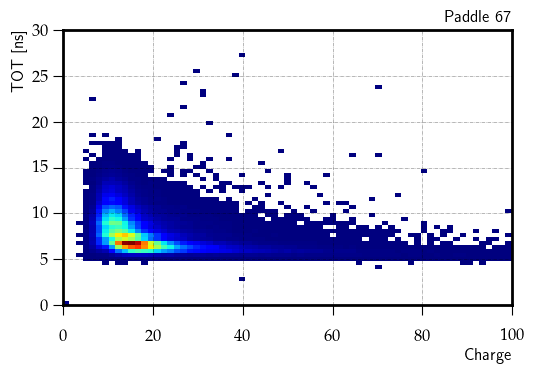

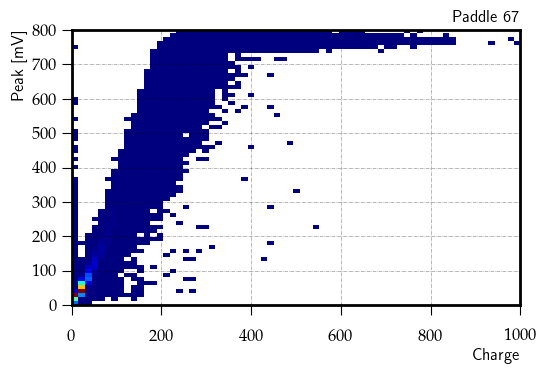

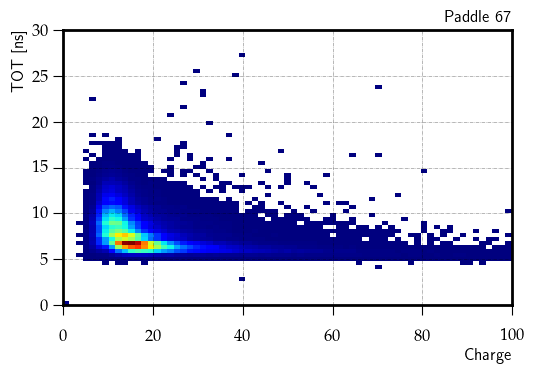

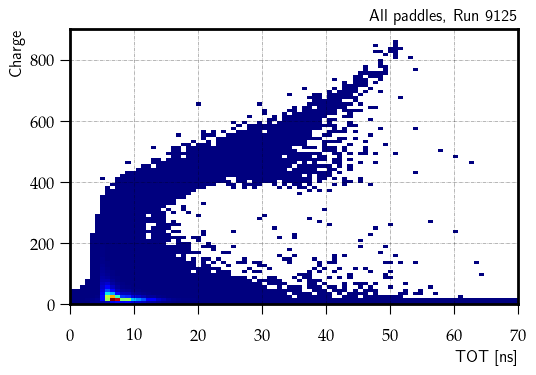

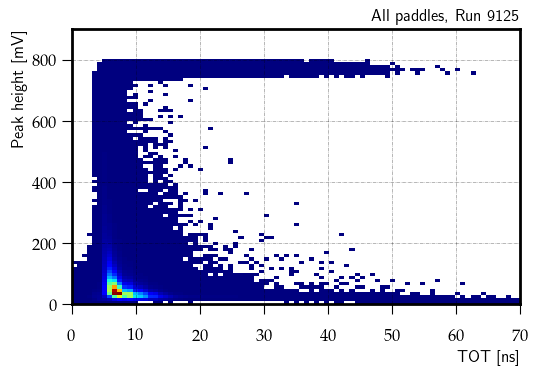

In [49]:
%matplotlib inline

nbins_charge = 70
nbins_tot    = 70
nbins_peak   = 70
nbins_max    = 70

peak_tot     = 780
paddle_id    = 67
run_id       = 9125

all_cha_a = []
all_tot_a = []
all_max_a = []
for k in range(1,161):
#for k in range(1,13):
    all_cha_a.extend(wf_data[k]['ch_a'])
    all_tot_a.extend(wf_data[k]['tot_a'])    
    all_max_a.extend(wf_data[k]['max_a'])

bins = (np.linspace(0,100, nbins_charge), np.linspace(0,30,nbins_tot))
fig = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE)
ax  = fig.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.set_title(f'Paddle {paddle_id}',loc='right')
ax.set_xlabel(f'Charge', loc='right')
ax.set_ylabel(f'TOT [ns]', loc='top')
h = d.factory.hist2d((wf_data[paddle_id]['ch_a'], wf_data[paddle_id]['tot_a']), bins)
h.imshow()

bins = (np.linspace(0,1000, nbins_charge), np.linspace(0,800,nbins_tot))
fig4 = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE)
ax4  = fig4.gca()
ax4.spines['top'].set_visible(True)
ax4.spines['right'].set_visible(True)
ax4.set_title(f'Paddle {paddle_id}',loc='right')
ax4.set_xlabel(f'Charge', loc='right')
ax4.set_ylabel(f'Peak [mV]', loc='top')
h4 = d.factory.hist2d((all_cha_a, all_max_a), bins)
h4.imshow()

bins = (np.linspace(0,100, nbins_charge), np.linspace(0,30,nbins_max))
fig = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE)
ax  = fig.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.set_title(f'Paddle {paddle_id}',loc='right')
ax.set_xlabel(f'Charge', loc='right')
ax.set_ylabel(f'TOT [ns]', loc='top')
h = d.factory.hist2d((wf_data[paddle_id]['ch_a'], wf_data[paddle_id]['tot_a']), bins)
h.imshow()

nbins_peak, nbins_tot = 90,90
bins = (np.linspace(0,900, nbins_peak), np.linspace(0,70,nbins_tot))
bins_inv = (np.linspace(0,70,nbins_tot), np.linspace(0,900, nbins_peak))
fig2 = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE)
ax2  = fig2.gca()
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)
#ax2.set_title(f'Paddle {paddle_id}',loc='right')
ax2.set_title(f'All paddles, Run {run_id}',loc='right')
#ax2.set_xlabel(f'Peak height [mV]', loc='right')
#ax2.set_ylabel(f'TOT [ns]', loc='top')
ax2.set_ylabel(f'Charge', loc='top')
ax2.set_xlabel(f'TOT [ns]', loc='right')
#h2 = d.factory.hist2d((wf_data[paddle_id]['ch_a'], wf_data[paddle_id]['tot_a']), bins)
#h2 = d.factory.hist2d((all_cha_a, all_tot_a), bins)
h2 = d.factory.hist2d((all_tot_a, all_cha_a), bins_inv)
h2.imshow()

nbins_peak, nbins_tot = 90,90
bins = (np.linspace(0,900, nbins_peak), np.linspace(0,70,nbins_tot))
bins_inv = (np.linspace(0,70,nbins_tot), np.linspace(0,900, nbins_peak))
fig3 = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE)
ax3  = fig3.gca()
ax3.spines['top'].set_visible(True)
ax3.spines['right'].set_visible(True)
#ax2.set_title(f'Paddle {paddle_id}',loc='right')
ax3.set_title(f'All paddles, Run {run_id}',loc='right')
#ax2.set_xlabel(f'Peak height [mV]', loc='right')
#ax2.set_ylabel(f'TOT [ns]', loc='top')
ax3.set_ylabel(f'Peak height [mV]', loc='top')
ax3.set_xlabel(f'TOT [ns]', loc='right')
#h2 = d.factory.hist2d((wf_data[paddle_id]['ch_a'], wf_data[paddle_id]['tot_a']), bins)
#h2 = d.factory.hist2d((all_cha_a, all_tot_a), bins)
h3 = d.factory.hist2d((all_tot_a, all_max_a), bins_inv)
h3.imshow()


plt.show()

249837.03125
499.67425537109375


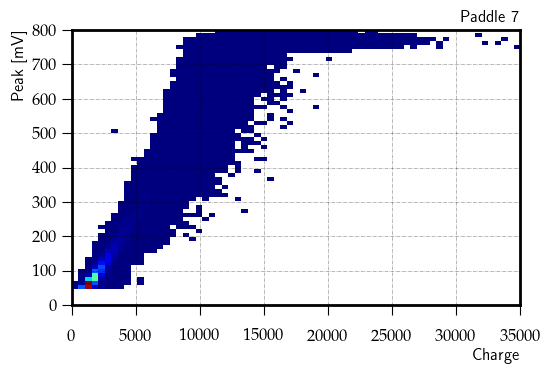

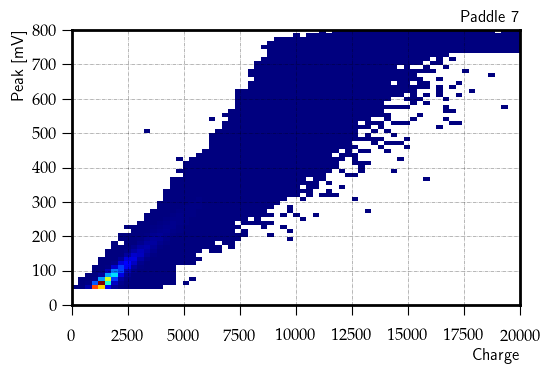

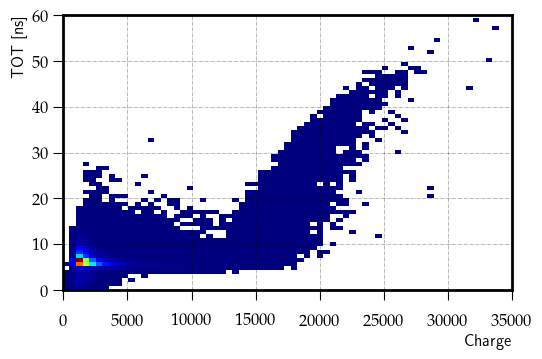

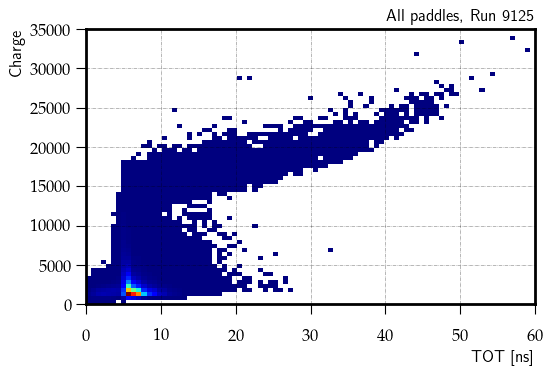

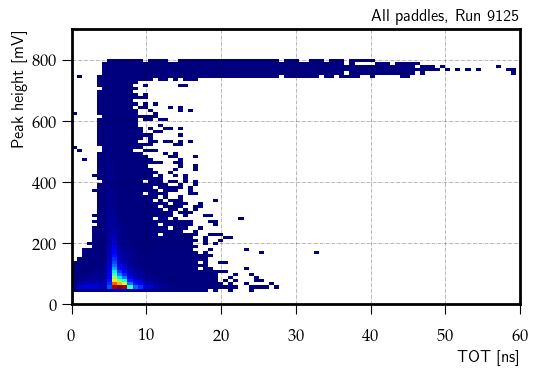

In [4]:
%matplotlib inline

# this is for trapezoidal charge calculation

nbins_charge = 70
nbins_tot    = 70
nbins_peak   = 70
nbins_max    = 70

peak_tot     = 780
paddle_id    = 7
run_id       = 9125


all_cha_a = []
all_tot_a = []
all_max_a = []
for k in range(1,161):
#for k in range(1,13):
    all_cha_a.extend(wf_data[k]['ch_a'])
    all_tot_a.extend(wf_data[k]['tot_a'])    
    all_max_a.extend(wf_data[k]['max_a'])

print (max(all_cha_a))
print (max(all_tot_a))

max_tot  = 60
max_peak = 800
#raise

bins = (np.linspace(0,35000, nbins_charge), np.linspace(0,max_peak,nbins_peak))
fig = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE)
ax  = fig.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.set_title(f'Paddle {paddle_id}',loc='right')
ax.set_xlabel(f'Charge', loc='right')
ax.set_ylabel(f'Peak [mV]', loc='top')
#h = d.factory.hist2d((wf_data[paddle_id]['ch_a'], wf_data[paddle_id]['max_a']), bins)
h = d.factory.hist2d((all_cha_a, all_max_a), bins)

h.imshow()

bins = (np.linspace(0,20000, nbins_charge), np.linspace(0,800,nbins_max))
fig4 = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE)
ax4  = fig4.gca()
ax4.spines['top'].set_visible(True)
ax4.spines['right'].set_visible(True)
ax4.set_title(f'Paddle {paddle_id}',loc='right')
ax4.set_xlabel(f'Charge', loc='right')
ax4.set_ylabel(f'Peak [mV]', loc='top')
h4 = d.factory.hist2d((all_cha_a, all_max_a), bins)
h4.imshow()

bins = (np.linspace(0,35000, nbins_charge), np.linspace(0,max_tot,nbins_tot))
fig = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE)
ax  = fig.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
#ax.set_title(f'Paddle {paddle_id}',loc='right')
ax.set_xlabel(f'Charge', loc='right')
ax.set_ylabel(f'TOT [ns]', loc='top')
#h = d.factory.hist2d((wf_data[paddle_id]['ch_a'], wf_data[paddle_id]['tot_a']), bins)
h = d.factory.hist2d((all_cha_a, all_tot_a), bins)
h.imshow()

nbins_peak, nbins_tot = 90,90
bins = (np.linspace(0,900, nbins_peak), np.linspace(0,max_tot,nbins_tot))
bins_inv = (np.linspace(0,max_tot,nbins_tot), np.linspace(0,35000, nbins_charge))
fig2 = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE)
ax2  = fig2.gca()
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)
#ax2.set_title(f'Paddle {paddle_id}',loc='right')
ax2.set_title(f'All paddles, Run {run_id}',loc='right')
#ax2.set_xlabel(f'Peak height [mV]', loc='right')
#ax2.set_ylabel(f'TOT [ns]', loc='top')
ax2.set_ylabel(f'Charge', loc='top')
ax2.set_xlabel(f'TOT [ns]', loc='right')
#h2 = d.factory.hist2d((wf_data[paddle_id]['ch_a'], wf_data[paddle_id]['tot_a']), bins)
#h2 = d.factory.hist2d((all_cha_a, all_tot_a), bins)
h2 = d.factory.hist2d((all_tot_a, all_cha_a), bins_inv)
h2.imshow()

nbins_peak, nbins_tot = 90,90
#bins = (np.linspace(0,900, nbins_peak), np.linspace(0,70,nbins_tot))
bins_inv = (np.linspace(0,max_tot,nbins_tot), np.linspace(0,900, nbins_peak))
fig3 = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE)
ax3  = fig3.gca()
ax3.spines['top'].set_visible(True)
ax3.spines['right'].set_visible(True)
#ax2.set_title(f'Paddle {paddle_id}',loc='right')
ax3.set_title(f'All paddles, Run {run_id}',loc='right')
#ax2.set_xlabel(f'Peak height [mV]', loc='right')
#ax2.set_ylabel(f'TOT [ns]', loc='top')
ax3.set_ylabel(f'Peak height [mV]', loc='top')
ax3.set_xlabel(f'TOT [ns]', loc='right')
#h2 = d.factory.hist2d((wf_data[paddle_id]['ch_a'], wf_data[paddle_id]['tot_a']), bins)
#h2 = d.factory.hist2d((all_cha_a, all_tot_a), bins)
h3 = d.factory.hist2d((all_tot_a, all_max_a), bins_inv)
h3.imshow()


plt.show()

In [41]:
missing_hits = 0

wf_data = { k : { 'ch_a' : [], 'ch_b' : [], 'max_a' : [], 'max_b' : [] , 'tot_a' : [], 'tot_b' : [] } for k in range(1,161)}

frac = 0.8
max_frames = 20e6

nframes = 0 

small_wf = None
large_wf = None
for reader in reader9125, reader10018:
    reader.rewind()
    for frame in tqdm.notebook.tqdm(reader, total=max_frames):
        if frame.has('PacketType.TofEvent'):
            nframes += 1
            if nframes >= max_frames:
                break
            ev = frame.get_tofevent('PacketType.TofEvent')
            if ev.has_any_mangling:
                continue
            hits = ev.hitmap 
            #print (ev.hits)
            for wf in ev.waveforms:
                wf.calibrate(calib[wf.rb_id])
                #print (hits)
                try:
                    hit = hits[wf.paddle_id]
                except KeyError:
                    missing_hits += 1
                    continue
                charge_a = hit.charge_a
                charge_b = hit.charge_b
                max_a    = hit.peak_a
                max_b    = hit.peak_b
                tot_a    = wf.get_tot_a(max_a*0.8)
                tot_b    = wf.get_tot_b(max_b*0.8) 
                wf_data[wf.paddle_id]['ch_a']  .append(hit.charge_a )
                wf_data[wf.paddle_id]['ch_b']  .append(hit.charge_b )
                wf_data[wf.paddle_id]['max_a'] .append(hit.peak_a   )
                wf_data[wf.paddle_id]['max_b'] .append(hit.peak_b   )
                wf_data[wf.paddle_id]['tot_a'] .append(wf.get_tot_a(hit.peak_a*frac)) 
                wf_data[wf.paddle_id]['tot_b'] .append(wf.get_tot_b(hit.peak_b*frac))
                if wf.get_tot_a(hit.peak_a*frac) > 50 and hit.peak_a < 200:
                    small_wf = wf
                if wf.get_tot_a(hit.peak_a*frac) > 50 and hit.peak_a  > 600 and hit.peak_a < 700:
                    large_wf = wf
                    print (hit)
                if large_wf is not None and small_wf is not None:
                    nframes = max_frames
            
                #print (wf)
            #print (ev)
            #break
    reader.rewind()
print ('Done')

  0%|          | 0/20000000.0 [00:00<?, ?it/s]

ERROR:Ch4 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch3 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch8 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch7 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch1 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch2 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch3 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch4 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch8 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch7 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch8 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch7 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch2 has 0 adc values, however we are expecting 1024!:tof:None:1244
ERROR:Ch1 has 0 adc values, however we are expectin

KeyboardInterrupt: 

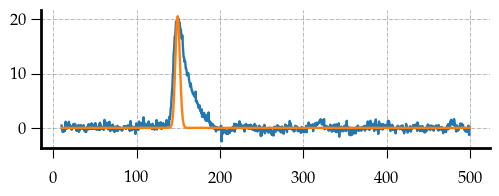

In [57]:
%matplotlib inline

fig = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE_HALF_HEIGHT)
ax  = fig.gca()
ax.plot(wf.times_a[20:], wf.voltages_a[20:])
ys = 7*wf.max_peak_a_guess*np.array(gon.stats.gamma_pdf(wf.times_a[20:], 3000, 1*wf.max_peak_a_guess))
ax.plot(wf.times_a[20:], ys)
#fig2 = plt.figure(figsize=lo.FIGSIZE_A4_LANDSCAPE_HALF_HEIGHT)
#ax2  = fig2.gca()
#ax2.plot(large_wf.times_a, large_wf.voltages_a)


In [17]:
len(ev.hits)
len(ev.waveforms)

4

In [18]:
ev

<PyO3Wrapper: <TofEvent (version <ProtocolVersion: Unknown>)
  EventID          : 1210043
  RunID            : 9125
  EventStatus      : <EventStatus: Unknown>
  TriggerSources   : [Track]
  NTrigPaddles     : 0
  DRS dead hits    : 0
  timestamp32      : 365384669
  timestamp16      : 40375
   |-> timestamp48 : 173409669960669
  ** ** TRIGGER HITS (DSI/J/CH) [3 LTBS] ** **
  => 1/2/(9,10) (<LTBThreshold: Hit>) 
  => 2/3/(1,2) (<LTBThreshold: Hit>) 
  => 2/4/(1,2) (<LTBThreshold: Hit>) 
  => 2/4/(3,4) (<LTBThreshold: Hit>) 
  ** ** MTB LINK IDs ** **
  => 3 14 16 17 
  == Trigger hits 4, expected RBEvents 4
  ** ** ** HITS ** ** **
  <TofHit (version : <ProtocolVersion: V1>):
  Paddle ID       32
  Peak:
    LE Time A/B   97.31 103.81   
    Height  A/B   57.59 52.44
    Charge  A/B   23.77 24.97
  ** paddle  ** 
    Length        1510.00
    Timing offset 0.00 (ns)
    Coax cbl time 8.76
    Hart cbl time 13.56
  ** reconstructed interaction
    energy_dep    2.07   
    pos_across   